## Pydantic Graph


In [7]:
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("GEMINI_API_KEY")

In [10]:
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(api_key=API_KEY, model="gemini-3.5-flash")
llm.invoke("salom nima yangiliklar").content[0]["text"]

"Salom! Men tomonda hamma narsa tinch, yangi bilimlar o'rganish va sizga yordam berish bilan bandman. 😊\n\nO'zingizda nima gaplar? Bugun sizga qanday yordam bera olaman? Biror qiziqarli mavzuda suhbatlashamizmi yoki aniq bir savolingiz bormi?"

In [12]:
from langchain_core.messages import HumanMessage

llm.invoke([HumanMessage(content="salom nima yangiliklar")]).content[0]["text"]

"Salom! Men tomonda hammasi tinch, har doimgidek sizga yordam berishga va savollaringizga javob berishga tayyorman. \n\nDunyoda, ayniqsa texnologiya, ilm-fan va sun'iy intellekt sohasida har kuni juda ko'p qiziqarli yangiliklar bo'lyapti. \n\nSizda nima gaplar? Bugun sizga qanday yordam bera olaman yoki qaysi mavzuda suhbatlashamiz?"

In [32]:
from pydantic import BaseModel
from typing import TypedDict, List


class graph_schema(BaseModel):
    user_message: str
    all_messages: List


In [48]:
def generate_video_idea(schema: graph_schema):
    schema = schema.model_dump()
    user_message = schema["user_message"]
    response_ai = llm.invoke([HumanMessage(content=user_message)])
    schema["all_messages"] = [user_message] + [response_ai]
    return schema


def generate_video_prompt(schema: graph_schema):
    schema = schema.model_dump()
    user_message = schema["user_message"]
    response_ai = llm.invoke([HumanMessage(content=user_message)])
    schema["all_messages"] = [user_message] + [response_ai]
    return schema



In [49]:
from langgraph.graph import START, END, StateGraph

graph = StateGraph(graph_schema)
graph.add_node("generate_video_idea", generate_video_idea)
graph.add_node("generate_video_prompt", generate_video_prompt)

graph.add_edge(START, "generate_video_idea")
graph.add_edge("generate_video_idea", "generate_video_prompt")
graph.add_edge("generate_video_prompt", END)

graph_pydantic = graph.compile()







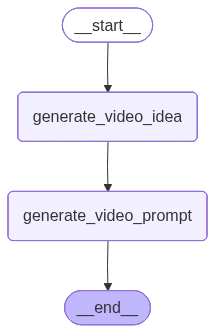

In [45]:
from IPython.display import Image, display

display(Image(graph_pydantic.get_graph().draw_mermaid_png()))

In [50]:
natija = graph_pydantic.invoke({
    "user_message": "Salom yangi video yaratib ber",
    "all_messages": [],
})
natija

{'user_message': 'Salom yangi video yaratib ber',
 'all_messages': ['Salom yangi video yaratib ber',
  AIMessage(content=[{'type': 'text', 'text': "Salom! Men sizga yangi video yaratishda bajonidil yordam beraman. \n\nTo'g'ridan-to'g'ri tayyor video faylni (MP4) formatida yuklab bera olmasam ham, video yaratish jarayonini **boshidan oxirigacha** qilib berishim mumkin. \n\nMen sizga quyidagilarda yordam bera olaman:\n1. **Video g'oyasi va ssenariysi:** Video uchun qiziqarli mavzu, gapiriladigan matn (audio diktor uchun) va kadrlar rejasini yozib beraman.\n2. **AI video generatorlari uchun promptlar (buyruqlar):** Runway, Sora, Pika, yoki Midjourney kabi neyrotarmoqlarda video va rasm chiqarish uchun ingliz tilida mukammal yozma buyruqlar tayyorlab beraman.\n3. **Yutub, TikTok yoki Instagram Reels uchun reja:** Videongiz trendga chiqishi uchun qanday boshlash va qanday montaj qilish kerakligini tushuntiraman.\n\n**Boshlashimiz uchun menga quyidagilarni ayting:**\n* Videongiz **qaysi mavz